## Detecting Fake and True news by Gensim Model.

In [2]:
import pandas as pd
import numpy as np

In [60]:
import gensim.downloader
# Show all available models in gensim-data
models = list(gensim.downloader.info()['models'].keys())
for model in models:
    print(model)

fasttext-wiki-news-subwords-300
conceptnet-numberbatch-17-06-300
word2vec-ruscorpora-300
word2vec-google-news-300
glove-wiki-gigaword-50
glove-wiki-gigaword-100
glove-wiki-gigaword-200
glove-wiki-gigaword-300
glove-twitter-25
glove-twitter-50
glove-twitter-100
glove-twitter-200
__testing_word2vec-matrix-synopsis


### I have used Gensim embedding vector to train my model.
These are the gensim pretrain model and i have used **word2vec-google-news-300**
```
fasttext-wiki-news-subwords-300
conceptnet-numberbatch-17-06-300
word2vec-ruscorpora-300
word2vec-google-news-300
glove-wiki-gigaword-50
glove-wiki-gigaword-100
glove-wiki-gigaword-200
glove-wiki-gigaword-300
glove-twitter-25
glove-twitter-50
glove-twitter-100
glove-twitter-200
```

In [8]:
fake = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\Program\AI ML\dataset\news_data\Fake.csv")
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


```
fake = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\Program\AI ML\dataset\news_data\Fake.csv")
fake.head()
```
**Note :-** 
- Use your own dataset path before running the code


In [9]:
fake['label'] = 0
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


### Assign Labels to the Fake News Dataset

A new column named `label` is added to the fake news dataset. The value `0` is assigned to every row to indicate that the news is **fake**.

```python
df_fake['label'] = 0
```

**Explanation:**
- `fake['label']` creates a new column named **label**.
- `= 0` assigns the value **0** to all rows in the dataset.
- Here, **0** represents **Fake News**.

In [6]:
true = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\Program\AI ML\dataset\news_data\True.csv")

```
true = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\Program\AI ML\dataset\news_data\True.csv")
```
**Note :-**
- Here also use your own dataset path .

In [11]:
true['label'] = 1
true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


### Assign Labels to the Fake News Dataset

A new column named `label` is added to the true news dataset. The value `1` is assigned to every row to indicate that the news is **true**.

```python
true['label'] = 1
```

**Explanation:**
- `true['label']` creates a new column named **label**.
- `= 1` assigns the value **0** to all rows in the dataset.
- Here, **0** represents **True News**.

In [12]:
df = pd.concat([true,fake], axis = 0 , ignore_index = True)
df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


### Merge the Datasets

The `pd.concat()` function is used to combine the **true news** and **fake news** datasets into a single DataFrame.

```python
df = pd.concat([true, fake], axis=0, ignore_index=True)
df.head()
```

**Explanation:**
- `pd.concat([true, fake])` combines the two DataFrames (`true` and `fake`).
- `axis=0` merges them **row-wise** (one DataFrame below the other).
- `ignore_index=True` creates a new sequential index (0, 1, 2, ...) instead of keeping the original indices.

In [22]:
df.title.iloc[10]

'Jones certified U.S. Senate winner despite Moore challenge'

In [25]:
df.label.value_counts()

0    23481
1    21417
Name: label, dtype: int64

Detecting the news using **News Title**

In [26]:
import gensim.downloader as API
model  = API.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


### download pretrain model. 

```
import gensim.downloader as API
model  = API.load('word2vec-google-news-300')
```
**Explanation :**
- `import gensim.downloader as API` import gensim downloader as API .
- `model  = API.load('word2vec-google-news-300')` than load gensim `word2vec-google-news-300`
- model size is 1662.8MB

In [36]:
model.similarity("cat","dog")

0.76094574

In [37]:
model.get_mean_vector(['Jones', 'certified', 'U.S.', 'Senate', 'winner', 'despite', 'Moore', 'challenge'])

array([ 2.56394465e-02,  3.08304036e-04, -3.48684378e-03, -2.73905741e-03,
        2.83987746e-02, -1.36397537e-02, -2.34210491e-02, -1.21589322e-02,
        4.41984348e-02,  1.73632354e-02, -2.69652475e-02,  1.87552744e-03,
       -7.72736873e-03, -3.01065817e-02, -5.00473827e-02,  4.38274629e-02,
        2.46931184e-02,  2.62435642e-03,  2.09761644e-03, -1.34567404e-02,
       -3.60822398e-03,  3.97265144e-02, -1.15587683e-02, -2.41303816e-02,
        2.39773113e-02,  6.45568734e-03, -6.14884496e-02, -2.80200653e-02,
        7.18061626e-03,  1.40348272e-02,  4.12452929e-02, -3.17147747e-02,
       -3.35005447e-02, -2.07404662e-02,  5.20934165e-03,  8.53013713e-03,
        2.55567431e-02, -3.64512973e-03, -3.43757495e-03,  1.69671047e-03,
        1.61667708e-02, -3.63266841e-02,  3.63563411e-02,  6.25332966e-02,
       -2.93276981e-02,  2.31288113e-02,  9.91281308e-03,  2.75704227e-02,
        2.17666067e-02,  3.47109511e-02, -2.40911413e-02,  6.53158128e-03,
       -5.36093079e-02, -

In [28]:
import spacy
nlp = spacy.load("en_core_web_lg")

In [44]:
def embedding_vec(text):
    doc = nlp(text)
    process_token = []
    for token in doc:
        if token.is_punct or token.is_stop:
            continue
        process_token.append(token.lemma_)

    return model.get_mean_vector(process_token)

## Text Embedding Function

The `embedding_vec()` function converts a text sentence into a numerical vector (embedding) using a pre-trained word embedding model.

### Steps Performed
1. Process the input text using the **spaCy** NLP pipeline.
2. Remove **punctuation** and **stop words**.
3. Convert each remaining token to its **lemma** (base form).
4. Generate the **mean word embedding vector** for all processed tokens using the pre-trained embedding model.
5. Return the resulting embedding vector, which can be used as input for machine learning models.

In [48]:
embedding_vec("Jones certified U.S. Senate winner despite Moore challenge").shape

(300,)

In [50]:
df["text_vec"] = df['title'].apply(lambda x : embedding_vec(x))

## Generate Text Embeddings

The following code applies the `embedding_vec()` function to every value in the `title` column.

- Each title is converted into a numerical embedding vector.
- The generated vector represents the semantic meaning of the text.
- The resulting embeddings are stored in a new column named **`text_vec`**.


In [55]:
x = np.stack(df['text_vec'])
y = df['label']

### Convert Feature Vectors into 2D NumPy Arrays

The text vectors are converted into two-dimensional NumPy arrays so they can be used as input for machine learning models.

```python
x = np.stack(df['text_vec'])
```

**Explanation:**
- `df['text_vec']` contain the text vectors generated by the densim model.
- `np.stack()` combines the individual vectors into a single **2D NumPy array**.
- `x` stores the training feature vectors.
- Each row in the resulting array represents one news article, and each column represents one feature of its vector embedding.

In [78]:
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report , confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42, stratify=y)

In [66]:
# param_grid = {
#     "n_estimators": [100, 300, 500],
#     "max_depth": [10, 20, None],
#     "min_samples_split": [2, 5],
#     "min_samples_leaf": [1, 2],
#     "max_features": ["sqrt", "log2"]
# }

# grid = GridSearchCV(
#     RandomForestClassifier(random_state=42),
#     param_grid,
#     cv=5,
#     scoring="accuracy",
#     n_jobs=-1
# )

# grid.fit(X_train, y_train)

# print(grid.best_params_)
# print(grid.best_score_)

### Model training.
Using this embedding vector train some ML model.

In [69]:
clf = GradientBoostingClassifier()
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7045
           1       0.95      0.96      0.96      6425

    accuracy                           0.96     13470
   macro avg       0.96      0.96      0.96     13470
weighted avg       0.96      0.96      0.96     13470



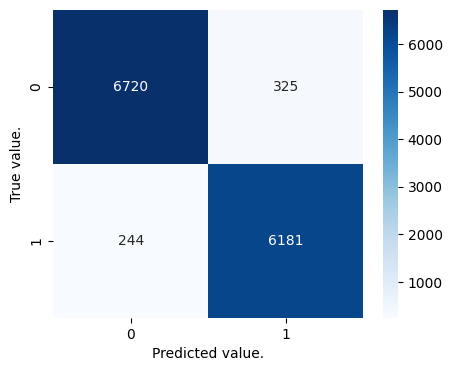

In [72]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm , annot=True , fmt='d' , cmap="Blues")
plt.ylabel("True value.")
plt.xlabel("Predicted value.")
plt.show()

In [73]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth = 20,
    min_samples_split= 3,
    min_samples_leaf= 1,
    max_features="sqrt"
)

rf_clf.fit(X_train,y_train)

y_predict = rf_clf.predict(X_test)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96      7045
           1       0.95      0.97      0.96      6425

    accuracy                           0.96     13470
   macro avg       0.96      0.96      0.96     13470
weighted avg       0.96      0.96      0.96     13470



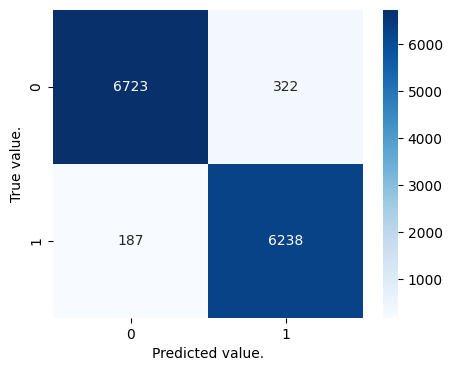

In [74]:
cm = confusion_matrix(y_test,y_predict)
plt.figure(figsize=(5,4))
sns.heatmap(cm , annot=True , fmt='d' , cmap="Blues")
plt.ylabel("True value.")
plt.xlabel("Predicted value.")
plt.show()

In [76]:
clf = KNeighborsClassifier(
    n_neighbors=4,
    weights='distance',
    metric='euclidean',
    )

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95      7045
           1       0.98      0.90      0.94      6425

    accuracy                           0.95     13470
   macro avg       0.95      0.94      0.95     13470
weighted avg       0.95      0.95      0.95     13470



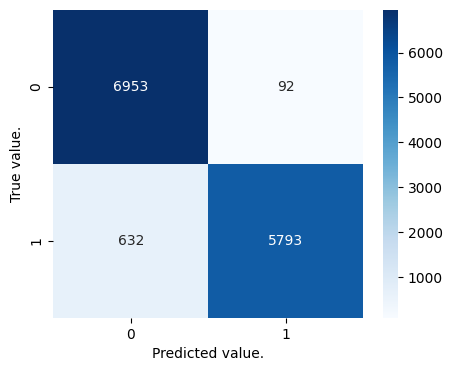

In [77]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm , annot=True , fmt='d' , cmap="Blues")
plt.ylabel("True value.")
plt.xlabel("Predicted value.")
plt.show()

In [79]:
y_prob = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

AUC Score: 0.9799615589608769


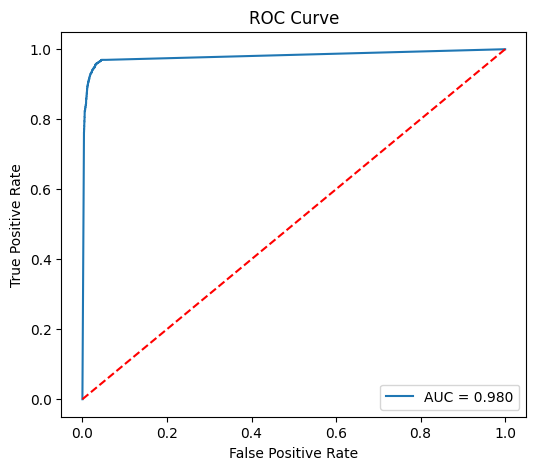

In [80]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], 'r--')   # Random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()